# importing libraries 

In [7]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# importing data

In [8]:
df_train = pd.read_excel('go_emotions_v2.xlsx')

In [9]:
filepath_2 = os.path.join(os.path.dirname(os.getcwd()), "data/group_4_url_1_transcript.csv")
df_test = pd.read_csv(filepath_2)
df_test = df_test.sample(n=len(df_test))

# training model

In [10]:
# Train on df_train
vectorizer = TfidfVectorizer(
    max_features=7000,        # Keep top N most frequent words
    ngram_range=(1, 2),       # (1,1) = unigrams, (1,2) = uni+bigrams
    min_df=2,                 # Ignore words appearing in < 2 documents
    max_df=0.95,              # Ignore words appearing in > 95% of docs
    sublinear_tf=True,        # Apply log scaling to term frequency
    use_idf=True,             # Use inverse document frequency
    norm='l2'                 # Normalize vectors to unit length
)
X_train_tfidf = vectorizer.fit_transform(df_train['text'])

model = MultinomialNB(alpha=1.0,                # Smoothing parameter (higher = more smoothing)
                      
                      fit_prior=True).fit(X_train_tfidf, df_train['emotion'])


# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Translation'])
predictions = model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
precision = precision_score(df_test['Emotion_core'], predictions, average='weighted')
recall = recall_score(df_test['Emotion_core'], predictions, average='weighted')
f1 = f1_score(df_test['Emotion_core'], predictions, average='weighted')

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(classification_report(df_test['Emotion_core'], predictions))

Accuracy:  0.494
Precision: 0.540
Recall:    0.494
F1-score:  0.426
              precision    recall  f1-score   support

       anger       0.60      0.08      0.14        37
     disgust       0.00      0.00      0.00        17
        fear       0.00      0.00      0.00        56
   happiness       0.33      0.59      0.43       198
     neutral       0.57      0.72      0.64       546
     sadness       1.00      0.02      0.04       104
    surprise       0.67      0.02      0.04        92

    accuracy                           0.49      1050
   macro avg       0.45      0.21      0.18      1050
weighted avg       0.54      0.49      0.43      1050



c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

# hyper parameter tuning

In [11]:
# Try different alpha values
for alpha in [0.1, 0.5, 1.0, 2.0]:
    model = MultinomialNB(alpha=alpha).fit(X_train_tfidf, df_train['emotion'])
    predictions = model.predict(X_test_tfidf)
    acc = accuracy_score(df_test['Emotion_core'], predictions)
    print(f"Alpha={alpha}: {acc:.3f}")

Alpha=0.1: 0.497
Alpha=0.5: 0.497
Alpha=1.0: 0.494
Alpha=2.0: 0.497


# error analysis

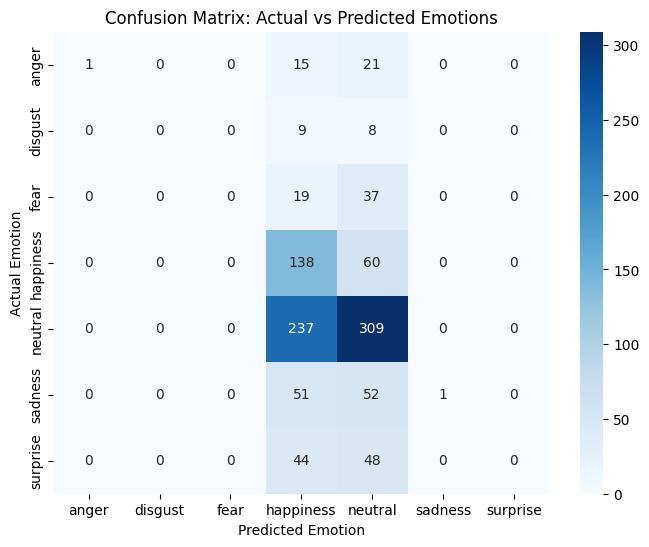


Prediction Distribution:
neutral      535
happiness    513
anger          1
sadness        1
Name: count, dtype: int64

Actual Distribution:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


In [12]:
# Train on df_train
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(df_train['text'])
model = MultinomialNB().fit(X_train_tfidf, df_train['emotion'])

# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Translation'])
predictions = model.predict(X_test_tfidf)

# Create confusion matrix
cm = confusion_matrix(df_test['Emotion_core'], predictions)
emotions = sorted(df_test['Emotion_core'].unique())


# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('Confusion Matrix: Actual vs Predicted Emotions')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Show prediction distribution
print("\nPrediction Distribution:")
print(pd.Series(predictions).value_counts())
print("\nActual Distribution:")
print(df_test['Emotion_core'].value_counts())